<a href="https://colab.research.google.com/github/mohana-25-tejasree/Ai-automatic-wieght-lifting-counter/blob/main/Titanic_EDA_Gamidi_mohana_tejasree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Run this cell in Colab to download the dataset automatically
import urllib.request
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
urllib.request.urlretrieve(url, 'titanic.csv')
print('Dataset downloaded successfully!')

Dataset downloaded successfully!


In [2]:
# Import all the libraries we need
import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for creating graphs
import seaborn as sns # for beautiful statistical graphs
import warnings
warnings.filterwarnings('ignore')
# Set a nice style for all our graphs
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('titanic.csv')
print('Dataset loaded!')
print(f'Shape: {df.shape}') # (rows, columns)
# Expected output: Shape: (891, 12)

Dataset loaded!
Shape: (891, 12)


In [3]:
# .head() shows the first 5 rows so we can see what the data looks like
df.head()
# Expected output: A table with 5 rows and 12 columns
# You will see columns like: PassengerId, Survived, Pclass, Name, Sex, Age ...

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# .info() tells us: column names, data types, and non-null counts
print('=== Dataset Info ===')
df.info()
# Expected output example:
# RangeIndex: 891 entries, 0 to 890
# Data columns (total 12 columns):
# # Column Non-Null Count Dtype
# --- ------ -------------- -----
# 0 PassengerId 891 non-null int64
# 1 Survived 891 non-null int64
# 2 Pclass 891 non-null int64
# 4 Sex 891 non-null object
# 5 Age 714 non-null float64 ← 177 missing values!
# 9 Fare 891 non-null float64
# ...

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# .describe() gives us count, mean, std, min, 25%, 50%, 75%, max
print('=== Descriptive Statistics ===')
df.describe().round(2)
# Key things to notice from the output:
# - Age: mean = 29.7 years, min = 0.42 (baby!), max = 80
# - Fare: mean = 32.2, max = 512.3 (very skewed!)
# - Survived: mean = 0.38 (only 38% survived)

=== Descriptive Statistics ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [6]:
# For text/category columns, .value_counts() is more useful
print('=== Survival Count ===')
print(df['Survived'].value_counts())
print(df['Survived'].value_counts(normalize=True).round(3) * 100)
# normalize=True gives percentage
print('\n=== Passenger Class ===')
print(df['Pclass'].value_counts().sort_index())
print('\n=== Gender Distribution ===')
print(df['Sex'].value_counts())
print('\n=== Port of Embarkation ===')
print(df['Embarked'].value_counts())

=== Survival Count ===
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.6
1    38.4
Name: proportion, dtype: float64

=== Passenger Class ===
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

=== Gender Distribution ===
Sex
male      577
female    314
Name: count, dtype: int64

=== Port of Embarkation ===
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [7]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
'Missing Count': missing,
'Missing Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)
print('=== Missing Values Summary ===')
print(missing_df[missing_df['Missing Count'] > 0])
# Expected output:
# Cabin 687 77.10% ← too many missing, we will drop this column
# Age 177 19.87% ← we will fill with median
# Embarked 2 0.22% ← we will fill with mode (most common value)

=== Missing Values Summary ===
          Missing Count  Missing Percentage
Cabin               687               77.10
Age                 177               19.87
Embarked              2                0.22


In [8]:
# STRATEGY 1: Drop the 'Cabin' column (77% missing — not useful)
df.drop(columns=['Cabin'], inplace=True)
print('Cabin column dropped.')
# STRATEGY 2: Fill Age with the MEDIAN (not mean, because Age has outliers)
# Median is less affected by extreme values than mean
age_median = df['Age'].median()
print(f'Filling Age with median: {age_median}')
df['Age'].fillna(age_median, inplace=True)
# STRATEGY 3: Fill Embarked with the MODE (most frequent value)
embarked_mode = df['Embarked'].mode()[0]
print(f'Filling Embarked with mode: {embarked_mode}')
df['Embarked'].fillna(embarked_mode, inplace=True)
# Verify: no more missing values
print('\nMissing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print("No missing values!" if df.isnull().sum().sum() == 0 else "Still some missing!")

Cabin column dropped.
Filling Age with median: 28.0
Filling Embarked with mode: S

Missing values after cleaning:
Series([], dtype: int64)
No missing values!


In [9]:
# Duplicate rows can skew our analysis
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')
# Remove duplicates if any exist
df.drop_duplicates(inplace=True)
print(f'Dataset shape after removing duplicates: {df.shape}')

Number of duplicate rows: 0
Dataset shape after removing duplicates: (891, 11)


In [10]:
# Create an 'AgeGroup' column to categorise passengers by age
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Middle Age', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
# Create a 'FamilySize' column = siblings + parents + self
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
# Create 'IsAlone' column — 1 if travelling alone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print('New columns added: AgeGroup, FamilySize, IsAlone')
print(df[['Age', 'AgeGroup', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))

New columns added: AgeGroup, FamilySize, IsAlone
    Age     AgeGroup  SibSp  Parch  FamilySize  IsAlone
0  22.0  Young Adult      1      0           2        0
1  38.0   Middle Age      1      0           2        0
2  26.0  Young Adult      0      0           1        1
3  35.0  Young Adult      1      0           2        0
4  35.0  Young Adult      0      0           1        1
5  28.0  Young Adult      0      0           1        1
6  54.0   Middle Age      0      0           1        1
7   2.0        Child      3      1           5        0
8  27.0  Young Adult      0      2           3        0
9  14.0         Teen      1      0           2        0


In [11]:
# Survival rate by gender
print('=== Survival Rate by Gender ===')
print(df.groupby('Sex')['Survived'].mean().round(3) * 100)
# Expected: female ~74%, male ~19%
# Survival rate by passenger class
print('\n=== Survival Rate by Passenger Class ===')
print(df.groupby('Pclass')['Survived'].mean().round(3) * 100)
# Expected: 1st class ~63%, 2nd class ~47%, 3rd class ~24%
# Average fare per class
print('\n=== Average Fare by Class ===')
print(df.groupby('Pclass')['Fare'].mean().round(2))
# Correlation matrix for numerical columns
print('\n=== Correlation Matrix ===')
print(df[['Survived','Pclass','Age','Fare','FamilySize']].corr().round(3))

=== Survival Rate by Gender ===
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

=== Survival Rate by Passenger Class ===
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64

=== Average Fare by Class ===
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

=== Correlation Matrix ===
            Survived  Pclass    Age   Fare  FamilySize
Survived       1.000  -0.338 -0.065  0.257       0.017
Pclass        -0.338   1.000 -0.340 -0.549       0.066
Age           -0.065  -0.340  1.000  0.097      -0.246
Fare           0.257  -0.549  0.097  1.000       0.217
FamilySize     0.017   0.066 -0.246  0.217       1.000


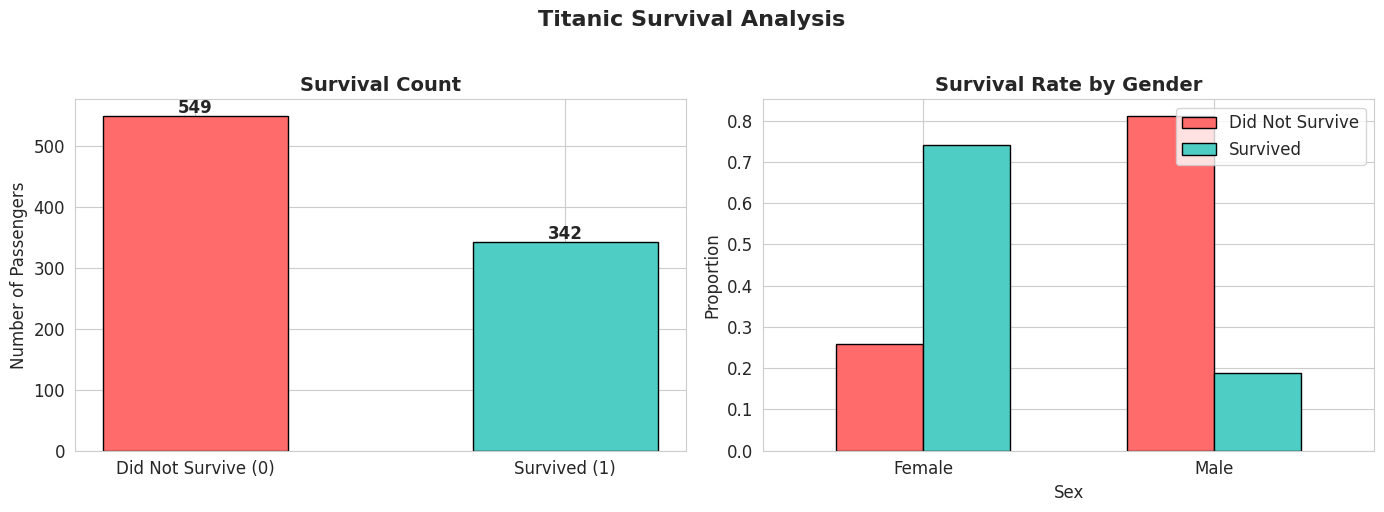

Key Insight: 74% of females survived vs only 19% of males!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left plot: Count of survivors vs non-survivors
survival_counts = df['Survived'].value_counts()
colors = ['#FF6B6B', '#4ECDC4'] # red=died, teal=survived
axes[0].bar(['Did Not Survive (0)', 'Survived (1)'],
survival_counts.values, color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Survival Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
# Add value labels on top of each bar
for i, v in enumerate(survival_counts.values):
  axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')
# Right plot: Survival rate by gender (grouped bar chart)
survival_by_sex =df.groupby('Sex')['Survived'].value_counts(normalize=True).unstack()
survival_by_sex.plot(kind='bar', ax=axes[1], color=['#FF6B6B','#4ECDC4'],
edgecolor='black', width=0.6)
axes[1].set_title('Survival Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['Did Not Survive', 'Survived'])
plt.suptitle('Titanic Survival Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_survival_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key Insight: 74% of females survived vs only 19% of males!')

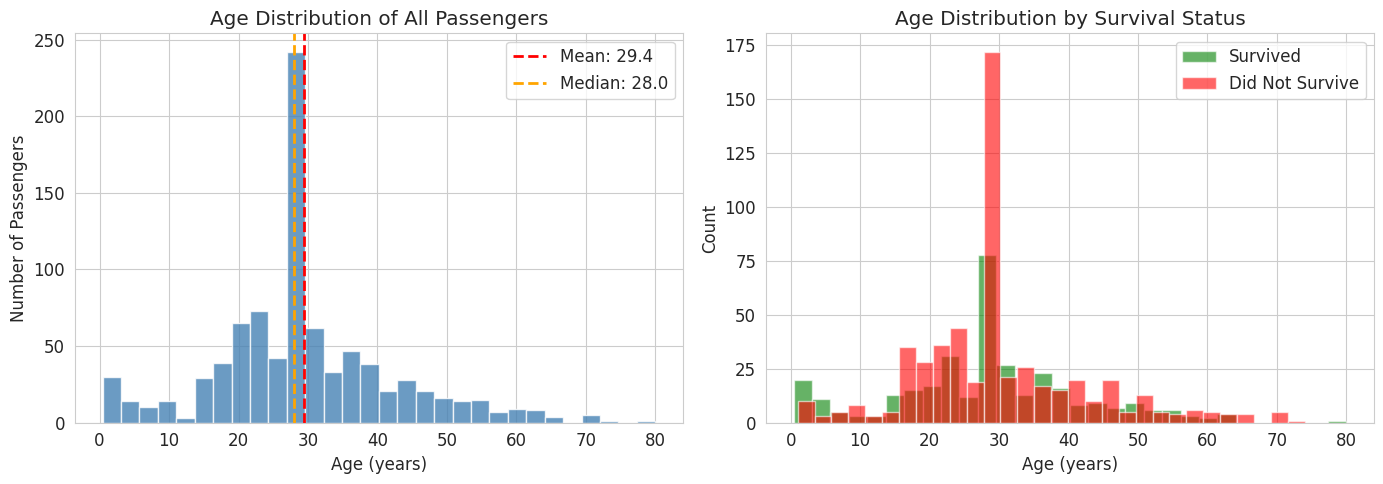

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Overall age distribution
axes[0].hist(df['Age'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2,
label=f"Mean: {df['Age'].mean():.1f}")
axes[0].axvline(df['Age'].median(), color='orange', linestyle='--', linewidth=2,
label=f"Median: {df['Age'].median():.1f}")
axes[0].set_title('Age Distribution of All Passengers')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Passengers')
axes[0].legend()
# Age distribution by survival (overlaid)
df[df['Survived']==1]['Age'].hist(ax=axes[1], bins=30, alpha=0.6,
color='green', label='Survived')
df[df['Survived']==0]['Age'].hist(ax=axes[1], bins=30, alpha=0.6,
color='red', label='Did Not Survive')
axes[1].set_title('Age Distribution by Survival Status')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.savefig('plot2_age_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

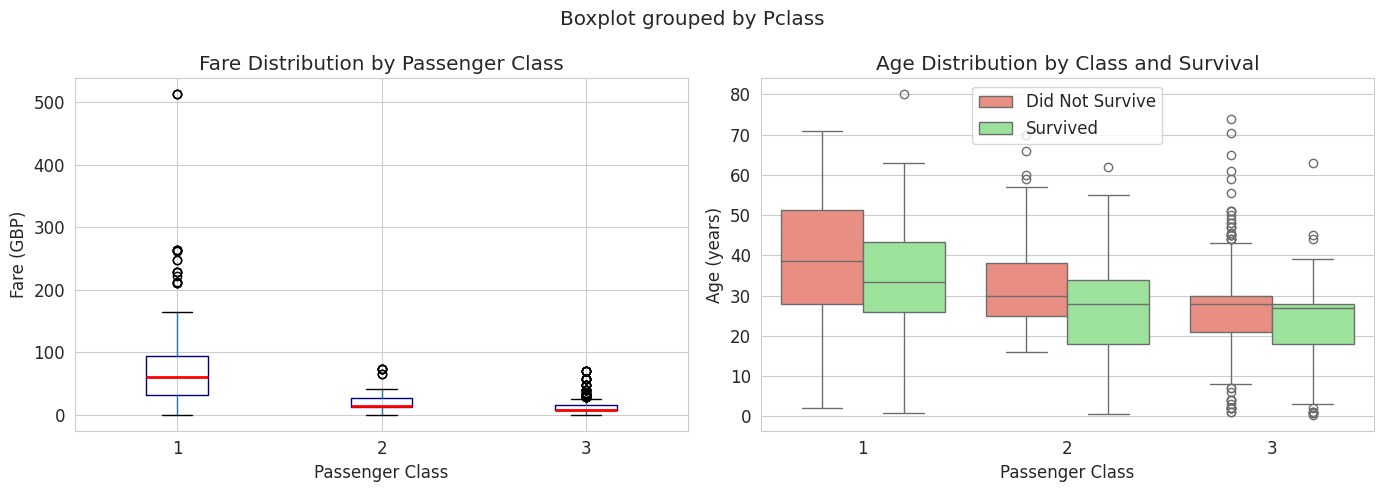

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Box plot: Fare by Passenger Class
df.boxplot(column='Fare', by='Pclass', ax=axes[0],
boxprops=dict(color='navy'),
medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Fare Distribution by Passenger Class')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Fare (GBP)')
plt.sca(axes[0])
plt.title('Fare Distribution by Passenger Class')
# Seaborn box plot: Age by Survival and Gender
sns.boxplot(data=df, x='Pclass', y='Age', hue='Survived',
palette={0:'salmon', 1:'lightgreen'}, ax=axes[1])
axes[1].set_title('Age Distribution by Class and Survival')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Age (years)')
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.savefig('plot3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

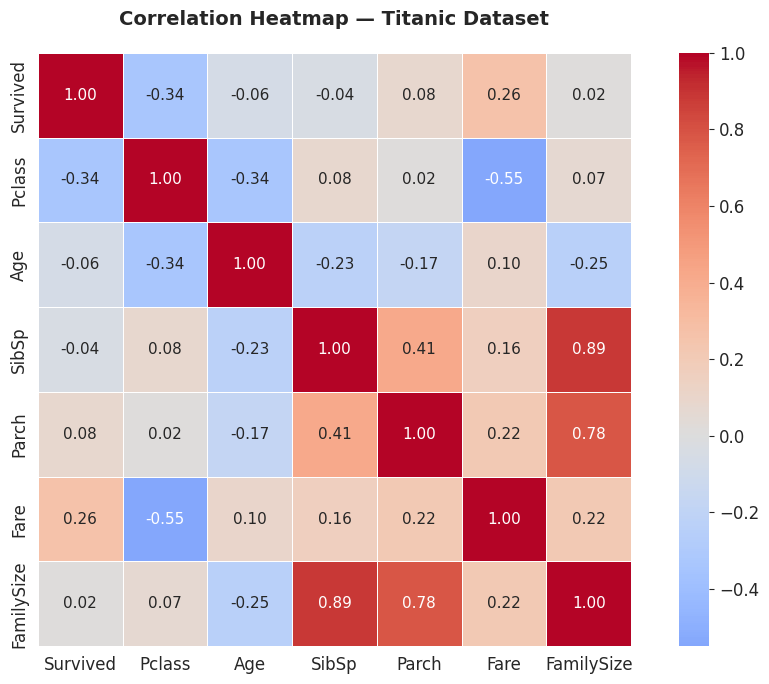

Key observations from heatmap:
- Fare vs Pclass: -0.55 (1st class passengers paid more)
- Survived vs Fare: +0.26 (higher fare = slightly better survival)
- Survived vs Pclass: -0.34 (lower class = lower survival)


In [17]:
plt.figure(figsize=(10, 7))
# Select only numerical columns for correlation
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
'FamilySize']
corr_matrix = df[numerical_cols].corr()
# Create the heatmap
sns.heatmap(corr_matrix,
annot=True, # show numbers inside cells
fmt='.2f', # 2 decimal places
cmap='coolwarm', # blue=negative, red=positive
center=0, # white at 0 correlation
square=True, # make cells square
linewidths=0.5, # grid lines between cells
annot_kws={'size': 11})
plt.title('Correlation Heatmap — Titanic Dataset', fontsize=14, fontweight='bold',
pad=20)
plt.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key observations from heatmap:')
print('- Fare vs Pclass: -0.55 (1st class passengers paid more)')
print('- Survived vs Fare: +0.26 (higher fare = slightly better survival)')
print('- Survived vs Pclass: -0.34 (lower class = lower survival)')

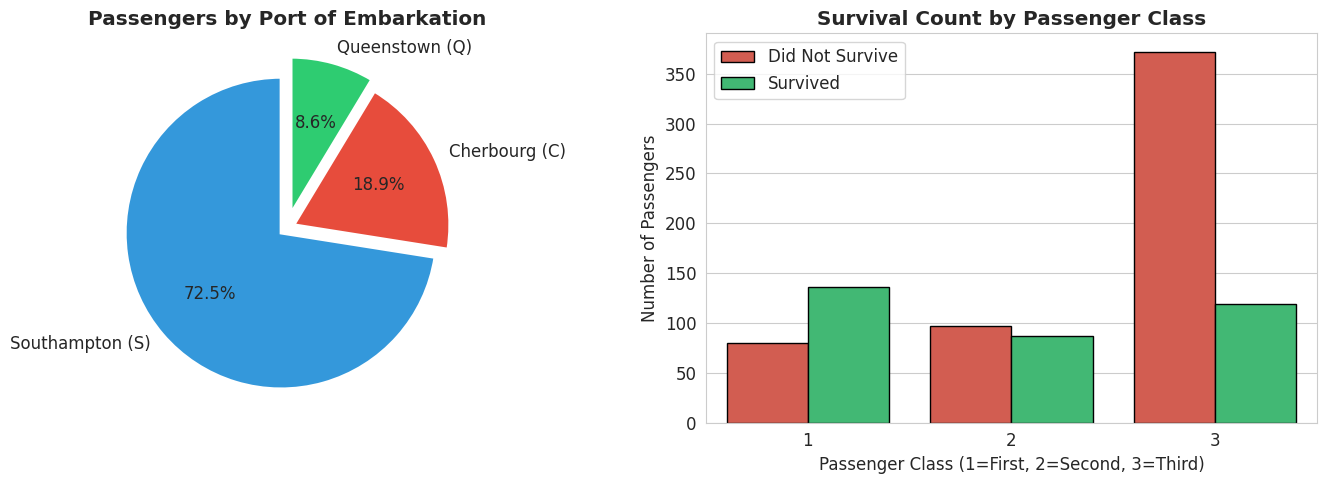

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Pie chart: passengers per embarkation port
embarked_counts = df['Embarked'].value_counts()
port_names = {'S': 'Southampton (S)', 'C': 'Cherbourg (C)', 'Q': 'Queenstown (Q)'}
labels = [port_names[p] for p in embarked_counts.index]
explode = (0.05, 0.05, 0.1) # slightly separate the slices
colors = ['#3498DB', '#E74C3C', '#2ECC71']
axes[0].pie(embarked_counts.values, labels=labels, autopct='%1.1f%%',
explode=explode, colors=colors, startangle=90,
wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Passengers by Port of Embarkation', fontweight='bold')
# Seaborn countplot: survival by passenger class
sns.countplot(data=df, x='Pclass', hue='Survived',
palette={0:'#E74C3C', 1:'#2ECC71'}, ax=axes[1],
edgecolor='black')
axes[1].set_title('Survival Count by Passenger Class', fontweight='bold')
axes[1].set_xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
axes[1].set_ylabel('Number of Passengers')
axes[1].legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.savefig('plot5_pie_countplot.png', dpi=150, bbox_inches='tight')
plt.show()

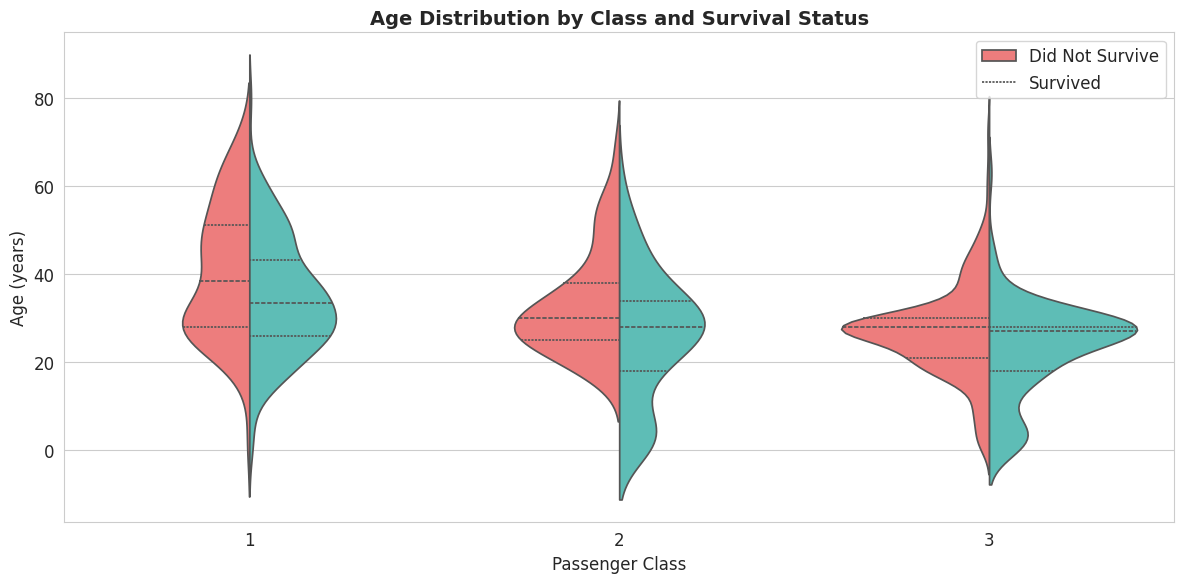

Key Insight: In 3rd class, younger passengers had slightly higher survival rates.


In [19]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived',
palette={0:'#FF6B6B', 1:'#4ECDC4'},
split=True, # split violin to compare survived vs not
inner='quart') # show quartile lines inside violin
plt.title('Age Distribution by Class and Survival Status', fontsize=14,
fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Age (years)')
plt.legend(['Did Not Survive', 'Survived'], loc='upper right')
plt.tight_layout()
plt.savefig('plot6_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key Insight: In 3rd class, younger passengers had slightly higher survival rates.')

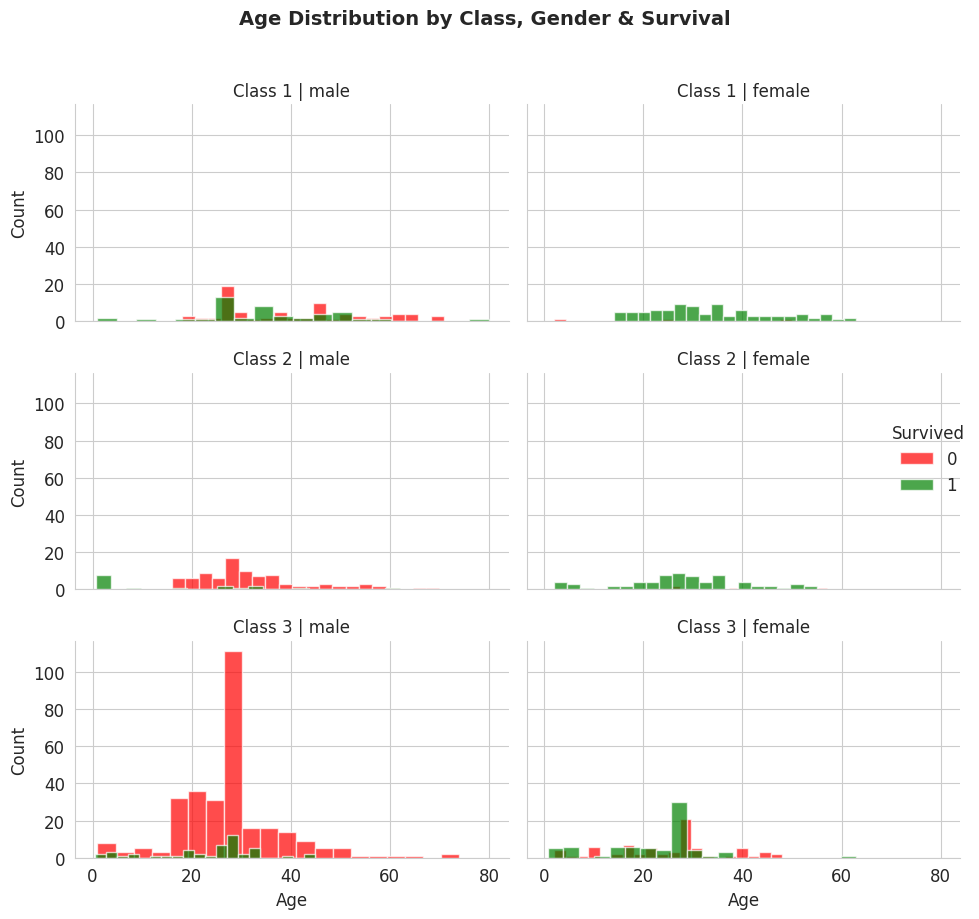

In [22]:
g = sns.FacetGrid(df, row='Pclass', col='Sex',
hue='Survived', palette={0:'red', 1:'green'},
height=3, aspect=1.5)
g.map(plt.hist, 'Age', bins=20, alpha=0.7, edgecolor='white')
g.add_legend(title='Survived')
g.set_axis_labels('Age', 'Count')
g.set_titles(row_template='Class {row_name}', col_template='{col_name}')
g.figure.suptitle('Age Distribution by Class, Gender & Survival', y=1.02,
fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_facetgrid.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
print('=' * 60)
print(' TITANIC DATASET - KEY FINDINGS SUMMARY')
print('=' * 60)

total = len(df)
survived = df['Survived'].sum()

print(f'\nTotal Passengers Analysed : {total}')
print(f'Total Survivors : {survived} ({survived/total*100:.1f}%)')
print(f'Total Deaths : {total-survived} ({(total-survived)/total*100:.1f}%)')

print('\n--- SURVIVAL BY GENDER ---')
for sex, rate in df.groupby('Sex')['Survived'].mean().items():
    print(f' {sex.capitalize():<8}: {rate*100:.1f}% survival rate')

print('\n--- SURVIVAL BY CLASS ---')
for cls, rate in df.groupby('Pclass')['Survived'].mean().items():
    label = {1:'First ', 2:'Second', 3:'Third '}[cls]
    bar = '#' * int(rate * 30)
    print(f' Class {label}: {bar} {rate*100:.1f}%')

print('\n--- AGE STATISTICS ---')
print(f' Average Age: {df["Age"].mean():.1f} years')
print(f' Youngest : {df["Age"].min():.1f} years')
print(f' Oldest : {df["Age"].max():.1f} years')

print('\n--- TOP INSIGHT ---')
print(' Women and children in 1st class had the highest survival rates.')
print(' Men in 3rd class had the lowest survival rates.')
print('=' * 60)

 TITANIC DATASET - KEY FINDINGS SUMMARY

Total Passengers Analysed : 891
Total Survivors : 342 (38.4%)
Total Deaths : 549 (61.6%)

--- SURVIVAL BY GENDER ---
 Female  : 74.2% survival rate
 Male    : 18.9% survival rate

--- SURVIVAL BY CLASS ---
 Class First : ################## 63.0%
 Class Second: ############## 47.3%
 Class Third : ####### 24.2%

--- AGE STATISTICS ---
 Average Age: 29.4 years
 Youngest : 0.4 years
 Oldest : 80.0 years

--- TOP INSIGHT ---
 Women and children in 1st class had the highest survival rates.
 Men in 3rd class had the lowest survival rates.
